# Olist End-to-End Analysis

This notebook loads the `archive` dataset, builds an order-level analytic dataset, and visualizes key business metrics for revenue, orders, delivery, payments, and review performance.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8')
DATA_DIR = Path('.') / 'archive'
assert DATA_DIR.exists(), 'Please ensure the archive folder is next to this notebook.'

In [2]:
customers = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv', dtype=str)
orders = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
])
items = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv', parse_dates=['shipping_limit_date'])
payments = pd.read_csv(DATA_DIR / 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(DATA_DIR / 'olist_order_reviews_dataset.csv', parse_dates=['review_creation_date', 'review_answer_timestamp'])
products = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv', dtype=str)
categories = pd.read_csv(DATA_DIR / 'product_category_name_translation.csv', dtype=str)
sellers = pd.read_csv(DATA_DIR / 'olist_sellers_dataset.csv', dtype=str)

products = products.merge(categories, on='product_category_name', how='left')
products['product_category_name_english'] = products['product_category_name_english'].fillna(products['product_category_name'])

items = items.merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left')

order_items = items.groupby('order_id', as_index=False).agg(
    order_item_count=('order_item_id', 'count'),
    total_product_value=('price', 'sum'),
    total_freight_value=('freight_value', 'sum'),
    average_item_price=('price', 'mean'),
    unique_products=('product_id', 'nunique'),
    unique_sellers=('seller_id', 'nunique'),
)
order_items['total_order_value'] = order_items['total_product_value'] + order_items['total_freight_value']

order_payments = payments.groupby('order_id', as_index=False).agg(
    payment_count=('payment_sequential', 'max'),
    total_payment_value=('payment_value', 'sum'),
    payment_types=('payment_type', lambda x: ', '.join(sorted(pd.unique(x)))),
    payment_installments=('payment_installments', 'max'),
)

order_reviews = reviews.groupby('order_id', as_index=False).agg(
    review_score=('review_score', 'mean'),
    review_count=('review_id', 'count'),
)

master = orders.merge(order_items, on='order_id', how='left')
master = master.merge(order_payments, on='order_id', how='left')
master = master.merge(order_reviews, on='order_id', how='left')
master = master.merge(customers, on='customer_id', how='left')

master['total_order_value'] = master['total_product_value'].fillna(0) + master['total_freight_value'].fillna(0)
master['approval_duration_hours'] = (master['order_approved_at'] - master['order_purchase_timestamp']).dt.total_seconds() / 3600
master['carrier_duration_hours'] = (master['order_delivered_carrier_date'] - master['order_approved_at']).dt.total_seconds() / 3600
master['customer_duration_hours'] = (master['order_delivered_customer_date'] - master['order_delivered_carrier_date']).dt.total_seconds() / 3600
master['estimate_gap_days'] = (master['order_delivered_customer_date'] - master['order_estimated_delivery_date']).dt.total_seconds() / 86400
master['order_cycle_days'] = (master['order_delivered_customer_date'] - master['order_purchase_timestamp']).dt.total_seconds() / 86400

master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_count,total_product_value,...,review_count,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,approval_duration_hours,carrier_duration_hours,customer_duration_hours,estimate_gap_days,order_cycle_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,29.99,...,1.0,7c396fd4830fd04220f754e42b4e5bff,03149,sao paulo,SP,0.178333,56.795833,145.503611,-7.107488,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,118.70,...,1.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,30.713889,11.109167,288.945833,-5.355729,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,159.90,...,1.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,0.276111,4.910278,220.274722,-17.245498,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,45.00,...,1.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,0.298056,89.900000,226.811944,-12.980069,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,19.90,...,1.0,72632f0f9dd73dfee390c9b22eb56dd6,09195,santo andre,SP,1.030556,21.434722,46.507778,-9.238171,2.873877


## Overview Metrics

In [3]:
overview = {
    'Orders': master['order_id'].nunique(),
    'Customers': master['customer_id'].nunique(),
    'Total Revenue': master['total_order_value'].sum(),
    'Average Order Value': master['total_order_value'].mean(),
    'Median Order Value': master['total_order_value'].median(),
    'Average Items per Order': master['order_item_count'].mean(),
    'Average Review Score': master['review_score'].mean(),
    'Late Delivery Ratio (%)': (master['estimate_gap_days'] > 0).mean() * 100,
    'Average Approval Time (h)': master['approval_duration_hours'].mean(),
    'Average Carrier Transit (h)': master['carrier_duration_hours'].mean(),
    'Average Customer Delivery (h)': master['customer_duration_hours'].mean(),
}
pd.DataFrame.from_dict(overview, orient='index', columns=['Value'])

,Value
Orders,9.944100e+04
Customers,9.944100e+04
Total Revenue,1.584355e+07
Average Order Value,1.593262e+02
Median Order Value,1.045600e+02
Average Items per Order,1.141731e+00
Average Review Score,4.086793e+00
Late Delivery Ratio (%),7.870999e+00
Average Approval Time (h),1.041909e+01
Average Carrier Transit (h),6.732092e+01


## Revenue by Product Category

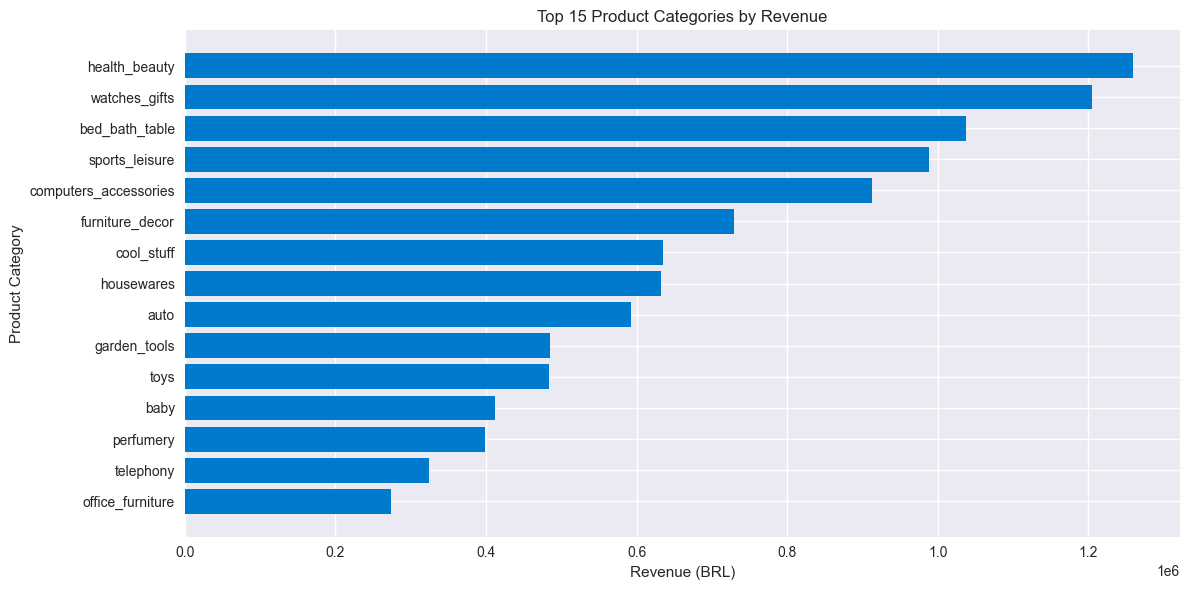

In [4]:
category_revenue = items.groupby('product_category_name_english', as_index=False).agg(
    revenue=('price', 'sum'),
    freight=('freight_value', 'sum'),
    orders=('order_id', 'nunique'),
    items_sold=('order_item_id', 'count'),
).sort_values('revenue', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(category_revenue['product_category_name_english'][::-1], category_revenue['revenue'][::-1], color='#007acc')
ax.set_title('Top 15 Product Categories by Revenue')
ax.set_xlabel('Revenue (BRL)')
ax.set_ylabel('Product Category')
plt.tight_layout()
plt.show()

## Order Status and Payment Mix

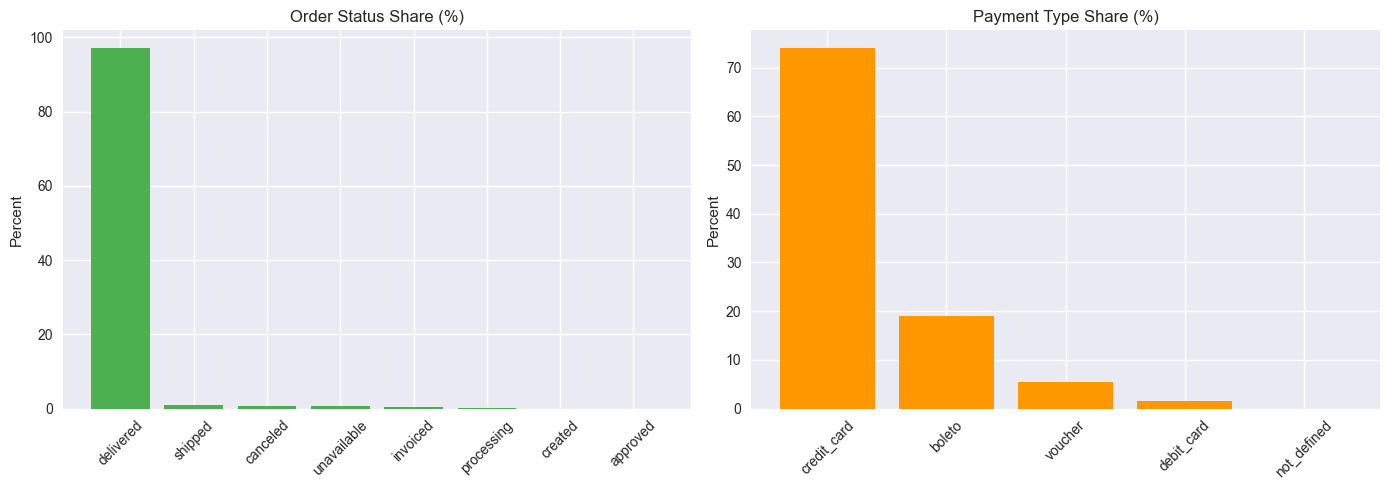

In [5]:
status_counts = orders['order_status'].value_counts(normalize=True).mul(100).sort_values(ascending=False)
payment_counts = payments['payment_type'].value_counts(normalize=True).mul(100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(status_counts.index, status_counts.values, color='#4caf50')
axes[0].set_title('Order Status Share (%)')
axes[0].set_ylabel('Percent')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(payment_counts.index, payment_counts.values, color='#ff9800')
axes[1].set_title('Payment Type Share (%)')
axes[1].set_ylabel('Percent')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Delivery Time Distributions

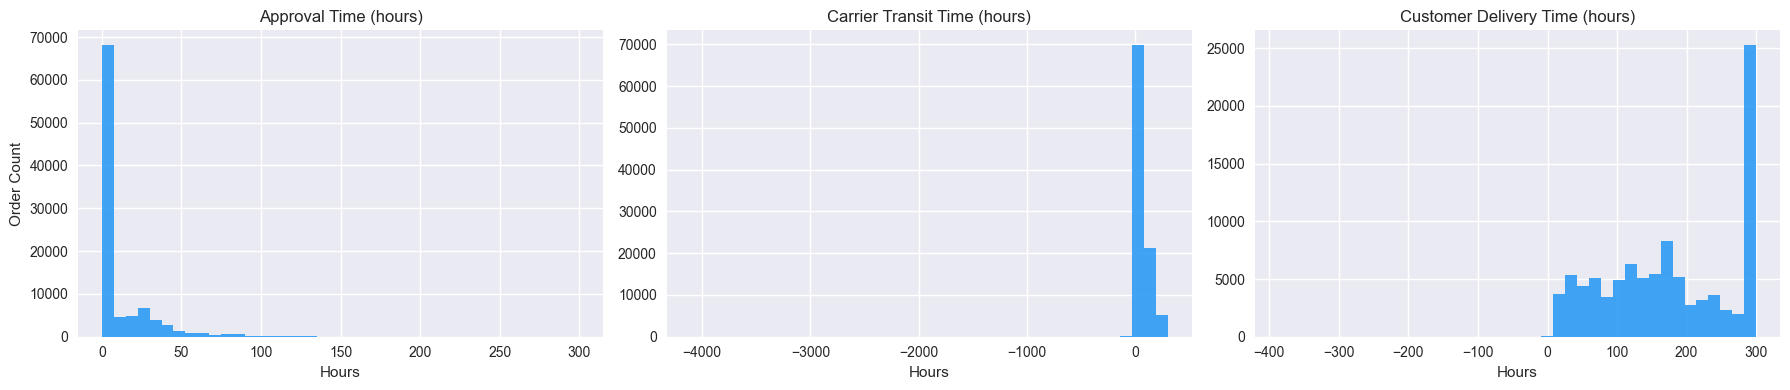

In [6]:
durations = master[['approval_duration_hours', 'carrier_duration_hours', 'customer_duration_hours']].copy()
durations = durations.replace([np.inf, -np.inf], np.nan).dropna()
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
for ax, col, title in [
    (axes[0], 'approval_duration_hours', 'Approval Time (hours)'),
    (axes[1], 'carrier_duration_hours', 'Carrier Transit Time (hours)'),
    (axes[2], 'customer_duration_hours', 'Customer Delivery Time (hours)'),
]:
    ax.hist(durations[col].clip(upper=300), bins=40, color='#2196f3', alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('Hours')

axes[0].set_ylabel('Order Count')
plt.tight_layout()
plt.show()

## Review Score Summary

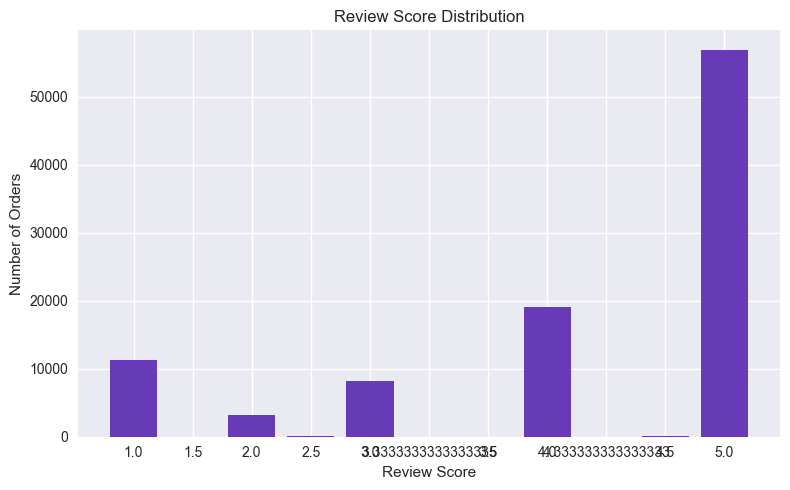

In [7]:
review_counts = master['review_score'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(review_counts.index.astype(str), review_counts.values, color='#673ab7')
ax.set_title('Review Score Distribution')
ax.set_xlabel('Review Score')
ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.show()

## Top Products by Revenue

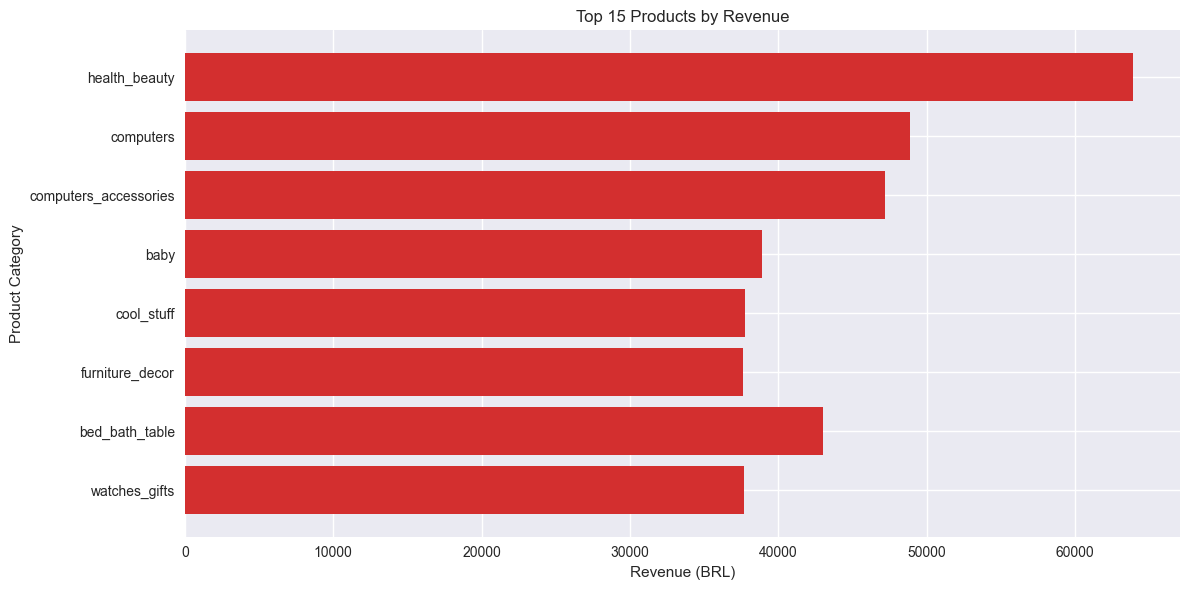

In [8]:
top_products = items.groupby('product_id', as_index=False).agg(
    revenue=('price', 'sum'),
    items_sold=('order_item_id', 'count'),
    unique_orders=('order_id', 'nunique')
).merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left')
top_products = top_products.sort_values('revenue', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_products['product_category_name_english'][::-1], top_products['revenue'][::-1], color='#d32f2f')
ax.set_title('Top 15 Products by Revenue')
ax.set_xlabel('Revenue (BRL)')
ax.set_ylabel('Product Category')
plt.tight_layout()
plt.show()

## Save Summaries
The analysis can be exported to CSV files for reporting or dashboarding.

In [9]:
RESULTS_DIR = Path('.') / 'analysis_results'
RESULTS_DIR.mkdir(exist_ok=True)
master.head(100).to_csv(RESULTS_DIR / 'order_master_sample.csv', index=False)
category_revenue.to_csv(RESULTS_DIR / 'category_revenue.csv', index=False)
status_counts.reset_index().rename(columns={'index': 'order_status', 'order_status': 'percent'}).to_csv(RESULTS_DIR / 'order_status_share.csv', index=False)
payment_counts.reset_index().rename(columns={'index': 'payment_type', 'payment_type': 'percent'}).to_csv(RESULTS_DIR / 'payment_type_share.csv', index=False)
review_counts.reset_index().rename(columns={'index': 'review_score', 'review_score': 'count'}).to_csv(RESULTS_DIR / 'review_score_distribution.csv', index=False)
top_products.to_csv(RESULTS_DIR / 'top_products.csv', index=False)
print(f'Saved CSV summaries to {RESULTS_DIR.resolve()}')

Saved CSV summaries to C:\Users\Elijah\Downloads\analysis_results
